# 🧠 ASD Detection — Paper-Ready Pipeline
### TabICLv2 vs XGBoost · LOOCV · Severity Scoring · Explainability

**Design principles (leak-free):**
| Guarantee | How |
|---|---|
| No test leakage in feature selection | FDR runs on participant-means of **training fold only** |
| No test leakage in model | `LeaveOneGroupOut` — left-out participant's trials never in training |
| No threshold circularity | Fixed 0.5 as primary; Youden-J reported as secondary after all folds complete |
| Severity score | Soft-vote P(ASD) mapped to Low / Borderline / High bands |
| Explainability | Per-participant local permutation importance + SHAP (XGBoost) |
| Baseline comparison | XGBoost identical LOOCV; McNemar significance test |


In [1]:
import subprocess, sys

PKGS = {
    'tabicl':      'tabicl[finetune]',
    'skrub':       'skrub',
    'sklearn':     'scikit-learn',
    'statsmodels': 'statsmodels',
    'pandas':      'pandas',
    'numpy':       'numpy',
    'matplotlib':  'matplotlib',
    'shap':        'shap',
    'joblib':      'joblib',
    'scipy':       'scipy',
    'tqdm':        'tqdm',
    'xgboost':     'xgboost',
}
for import_name, pip_name in PKGS.items():
    try:
        __import__(import_name)
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
print('✅ All dependencies ready')


Installing tabicl[finetune]...
Installing skrub...
✅ All dependencies ready


In [2]:
import os, sys, json, time, datetime, warnings, zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.stats              import shapiro, mannwhitneyu, ttest_ind
from tqdm.notebook            import tqdm
from sklearn.model_selection  import LeaveOneGroupOut
from sklearn.metrics          import (roc_auc_score, f1_score, recall_score,
                                      confusion_matrix, classification_report,
                                      accuracy_score, roc_curve, brier_score_loss)
from sklearn.pipeline         import Pipeline
from statsmodels.stats.multitest        import multipletests
from statsmodels.stats.contingency_tables import mcnemar

import shap
from xgboost   import XGBClassifier
from skrub     import TableVectorizer
from tabicl    import TabICLClassifier
try:
    from tabicl import FinetunedTabICLClassifier
    HAS_FINETUNE = True
except ImportError:
    HAS_FINETUNE = False
    print('⚠️  FinetunedTabICLClassifier not available')

import torch
print('✅ Imports ready')
print(f'   PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}  |  Fine-tune: {HAS_FINETUNE}')


✅ Imports ready
   PyTorch : 2.10.0+cu128  |  CUDA: True  |  Fine-tune: True


In [3]:
ZIP_PATH     = None
FEATURE_FILE = 'trial_features_tabpfn.csv'

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and ZIP_PATH is None and not os.path.exists(FEATURE_FILE):
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        ZIP_PATH = list(uploaded.keys())[0]

if ZIP_PATH and os.path.isfile(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    for root, dirs, files_ in os.walk('.'):
        for fname in files_:
            if fname == 'trial_features_tabpfn.csv':
                FEATURE_FILE = os.path.join(root, fname)
                break

# ── Core config ───────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
ALPHA         = 0.05
N_ESTIMATORS  = 64       # TabICLv2 ensemble size; use 128 for camera-ready
N_PERM        = 1000     # label-shuffle permutation test
N_BOOT        = 2000     # bootstrap CI iterations
HOLDOUT_RATIO = 0.20
META_COLS     = ['participant_id', 'trial', 'stimulus_type', 'label']
OUTPUT_DIR    = 'results_paper'
SPLIT_FILE    = os.path.join(OUTPUT_DIR, 'split_indices.json')
HOLDOUT_FLAG  = os.path.join(OUTPUT_DIR, '.holdout_used')

# Severity bands (applied to participant-level P(ASD) after soft-voting)
SEV_LOW   = 0.40   # P(ASD) < SEV_LOW  → Low risk
SEV_HIGH  = 0.70   # P(ASD) >= SEV_HIGH → High risk
           # SEV_LOW <= P(ASD) < SEV_HIGH → Borderline

# Fine-tune config (used only for final model, NOT inside LOOCV)
FINETUNE_LR     = 2e-5
FINETUNE_EPOCHS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config ready')
print(f'   Feature file : {FEATURE_FILE}')
print(f'   Output dir   : {OUTPUT_DIR}')
if not os.path.isfile(FEATURE_FILE):
    print(f'⚠️  WARNING: {FEATURE_FILE!r} not found — update FEATURE_FILE path above')


Saving Degraded_data (2).zip to Degraded_data (2).zip
✅ Config ready
   Feature file : ./Degraded_data/trial_features_tabpfn.csv
   Output dir   : results_paper


### Feature plain-language dictionary
Used in all explainability outputs so clinical readers understand what each metric means.


In [4]:
# Maps technical feature names → plain English for clinicians / paper tables
FEATURE_PLAIN = {
    'fix_count':            'Number of times eyes stopped to focus',
    'fix_dur_mean_ms':      'Average duration of each eye pause (ms)',
    'fix_dur_std_ms':       'Variability in eye pause duration',
    'fix_dur_max_ms':       'Longest single eye pause (ms)',
    'fix_dur_cv':           'Consistency of eye pauses (coefficient of variation)',
    'fix_rate_per_min':     'How often eyes paused per minute',
    'fix_dispersion_mean':  'How spread out eye pauses were across the screen',
    'fix_seq_norm':         'Orderliness of the eye-pause sequence',
    'ifd_mean':             'Average distance between consecutive eye pauses',
    'ifd_std':              'Variability in distance between eye pauses',
    'sac_count':            'Number of rapid eye jumps (saccades)',
    'sac_amplitude_mean':   'Average size of eye jumps',
    'sac_amplitude_std':    'Variability in eye jump size',
    'sac_rate_per_min':     'How often eyes made rapid jumps per minute',
    'sac_fix_ratio':        'Balance between eye jumps and eye pauses',
    'blink_count':          'Total number of blinks',
    'blink_dur_mean_ms':    'Average blink duration (ms)',
    'blink_rate_per_min':   'How often the participant blinked per minute',
    'blink_long_ratio':     'Proportion of unusually long blinks',
    'pupil_mean':           'Average pupil size',
    'pupil_std':            'Variability in pupil size',
    'pupil_asymmetry_mean': 'Average difference in size between left and right pupil',
    'pupil_asymmetry_std':  'Variability in pupil size asymmetry',
    'pupil_slope':          'How pupil size changed over the viewing session',
    'gaze_x_mean':          'Average horizontal gaze position on screen',
    'gaze_y_mean':          'Average vertical gaze position on screen',
}

def plain(feat):
    """Return plain-language label for a feature, falling back to raw name."""
    return FEATURE_PLAIN.get(feat, feat)

print('✅ Feature dictionary ready')
print(f'   {len(FEATURE_PLAIN)} features mapped to plain-language labels')


✅ Feature dictionary ready
   26 features mapped to plain-language labels


In [5]:
def load_data(path=FEATURE_FILE):
    if not os.path.exists(path):
        raise FileNotFoundError(f"'{path}' not found.")
    df = pd.read_csv(path, low_memory=False)
    df = df.dropna(axis=1, how='all')
    df = df[[c for c in df.columns if 'peak_vel' not in c]]
    feat_cols = [c for c in df.columns if c not in META_COLS]
    df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median())
    return df, feat_cols

df, feat_cols = load_data()
n_all = df['participant_id'].nunique()
asd_n = (df.groupby('participant_id')['label'].first() == 1).sum()
td_n  = (df.groupby('participant_id')['label'].first() == 0).sum()

print('✅ Data loaded')
print(f'   Participants : {n_all}  (ASD={asd_n}, TD={td_n})')
print(f'   Trials       : {len(df)}')
print(f'   Features     : {len(feat_cols)}')
print()
print('   Features not in plain-language dictionary:')
missing = [f for f in feat_cols if f not in FEATURE_PLAIN]
print(f'   {missing if missing else "None — all mapped ✅"}')


✅ Data loaded
   Participants : 57  (ASD=27, TD=30)
   Trials       : 1178
   Features     : 28

   Features not in plain-language dictionary:
   ['pupil_r_mean', 'pupil_r_std', 'pupil_l_mean', 'pupil_l_std']


In [6]:
def make_participant_split(df, holdout_ratio=HOLDOUT_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    parts = df[['participant_id', 'label']].drop_duplicates()
    asd_ids = parts[parts['label'] == 1]['participant_id'].tolist()
    td_ids  = parts[parts['label'] == 0]['participant_id'].tolist()
    rng.shuffle(asd_ids); rng.shuffle(td_ids)
    n_hold_asd = max(1, round(len(asd_ids) * holdout_ratio))
    n_hold_td  = max(1, round(len(td_ids)  * holdout_ratio))
    holdout_ids = asd_ids[:n_hold_asd] + td_ids[:n_hold_td]
    train_ids   = asd_ids[n_hold_asd:]  + td_ids[n_hold_td:]
    split = {
        'train_ids':   [str(x) for x in train_ids],
        'holdout_ids': [str(x) for x in holdout_ids],
        'seed': seed, 'holdout_ratio': holdout_ratio,
        'created': datetime.datetime.now().isoformat(),
        'n_train_asd': len(asd_ids) - n_hold_asd,
        'n_train_td':  len(td_ids)  - n_hold_td,
        'n_hold_asd':  n_hold_asd, 'n_hold_td': n_hold_td,
    }
    with open(SPLIT_FILE, 'w') as f: json.dump(split, f, indent=2)
    return train_ids, holdout_ids, split

def load_split():
    with open(SPLIT_FILE) as f: split = json.load(f)
    return split['train_ids'], split['holdout_ids'], split

if os.path.exists(SPLIT_FILE):
    train_ids, holdout_ids, split_info = load_split()
    print(f'✅ Loaded existing split from {SPLIT_FILE}')
else:
    train_ids, holdout_ids, split_info = make_participant_split(df)
    print(f'✅ Created new split → {SPLIT_FILE}')

df['participant_id'] = df['participant_id'].astype(str)
train_ids_s   = [str(x) for x in train_ids]
holdout_ids_s = [str(x) for x in holdout_ids]
df_train   = df[df['participant_id'].isin(train_ids_s)].copy()
df_holdout = df[df['participant_id'].isin(holdout_ids_s)].copy()

print(f'   Train   : {len(train_ids)} participants  (ASD={split_info["n_train_asd"]}, TD={split_info["n_train_td"]})')
print(f'   Holdout : {len(holdout_ids)} participants  (ASD={split_info["n_hold_asd"]}, TD={split_info["n_hold_td"]})')


✅ Created new split → results_paper/split_indices.json
   Train   : 46 participants  (ASD=22, TD=24)
   Holdout : 11 participants  (ASD=5, TD=6)


In [9]:
def make_tabicl(seed=RANDOM_STATE, n_est=N_ESTIMATORS):
    """Zero-shot TabICLv2 inside skrub pipeline. kv_cache=False is essential for LOOCV."""
    return Pipeline([
        ('prep', TableVectorizer(low_cardinality='passthrough')),
        ('clf',  TabICLClassifier(
            n_estimators=n_est, kv_cache=False, device=None, random_state=seed)),
    ])

def make_tabicl_finetuned(seed=RANDOM_STATE):
    """Fine-tuned TabICLv2 — only for final model after LOOCV."""
    if not HAS_FINETUNE:
        print('⚠️  Fine-tune unavailable — using zero-shot')
        return make_tabicl(seed)
    return Pipeline([
        ('prep', TableVectorizer(low_cardinality='passthrough')),
        ('clf',  FinetunedTabICLClassifier(
            learning_rate=FINETUNE_LR, epochs=FINETUNE_EPOCHS,
            device=None, random_state=seed)),
    ])

def make_xgb(seed=RANDOM_STATE):
    """XGBoost baseline — matched LOOCV, no ICL."""
    return XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=seed, verbosity=0)

print('✅ Model factories ready')
print(f'   TabICLv2 : n_estimators={N_ESTIMATORS}, kv_cache=False')
print(f'   XGBoost  : 300 trees, max_depth=4, lr=0.05')

✅ Model factories ready
   TabICLv2 : n_estimators=64, kv_cache=False
   XGBoost  : 300 trees, max_depth=4, lr=0.05


In [11]:
# ── FDR feature selection ─────────────────────────────────────────────────────
def fdr_select(X_part_means, y_part, alpha=ALPHA):
    """
    Benjamini-Hochberg FDR on participant-level means.
    X_part_means : DataFrame (one row per participant, columns = features)
    y_part       : 0/1 array aligned with X_part_means rows
    Returns list of significant column names (falls back to all if none survive).
    """
    cols, p_raw_list = X_part_means.columns.tolist(), []
    for col in cols:
        vals = X_part_means[col].values
        asd  = vals[y_part == 1]; td = vals[y_part == 0]
        asd  = asd[~np.isnan(asd)]; td = td[~np.isnan(td)]
        if len(asd) < 3 or len(td) < 3:
            p_raw_list.append(1.0); continue
        _, pa = shapiro(asd); _, pt = shapiro(td)
        if pa < 0.05 or pt < 0.05:
            _, p = mannwhitneyu(asd, td, alternative='two-sided')
        else:
            _, p = ttest_ind(asd, td, equal_var=False)
        p_raw_list.append(float(p))
    reject, _, _, _ = multipletests(p_raw_list, alpha=alpha, method='fdr_bh')
    sig = [c for c, r in zip(cols, reject) if r]
    return sig if sig else cols  # fallback: keep all

# ── Aggregate trial probabilities to participant level ────────────────────────
def aggregate_to_participant(pids, y_true, y_prob, threshold=0.5):
    agg = (pd.DataFrame({'participant_id': pids, 'y_true': y_true, 'y_prob': y_prob})
             .groupby('participant_id')
             .agg(y_true=('y_true','first'),
                  y_prob_mean=('y_prob','mean'),
                  n_trials=('y_prob','count'))
             .reset_index())
    agg['y_pred']  = (agg['y_prob_mean'] >= threshold).astype(int)
    agg['correct'] = (agg['y_true'] == agg['y_pred']).astype(int)
    return agg

# ── Severity scoring ──────────────────────────────────────────────────────────
def severity_label(p):
    if p < SEV_LOW:   return 'Low risk'
    if p < SEV_HIGH:  return 'Borderline'
    return 'High risk'

def add_severity(part_df):
    """Add severity band and numeric score (0-100) to participant DataFrame."""
    part_df = part_df.copy()
    part_df['severity_band']  = part_df['y_prob_mean'].apply(severity_label)
    part_df['severity_score'] = (part_df['y_prob_mean'] * 100).round(1)
    return part_df

# ── Bootstrap CIs ─────────────────────────────────────────────────────────────
def bootstrap_metrics(y_true, y_prob, threshold=0.5, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng    = np.random.default_rng(seed)
    y_true = np.array(y_true); y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int); n = len(y_true)
    boots  = {k: [] for k in ['auc','sens','spec','f1','acc','brier']}
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2: continue
        boots['auc'].append(roc_auc_score(yt, ypr))
        boots['sens'].append(recall_score(yt, yp, pos_label=1, zero_division=0))
        boots['spec'].append(recall_score(yt, yp, pos_label=0, zero_division=0))
        boots['f1'].append(f1_score(yt, yp, zero_division=0))
        boots['acc'].append(accuracy_score(yt, yp))
        boots['brier'].append(brier_score_loss(yt, ypr))
    point = {
        'auc':   roc_auc_score(y_true, y_prob),
        'sens':  recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'spec':  recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1':    f1_score(y_true, y_pred, zero_division=0),
        'acc':   accuracy_score(y_true, y_pred),
        'brier': brier_score_loss(y_true, y_prob),
    }
    result = {}
    for k, vals in boots.items():
        lo, hi = np.percentile(vals, [2.5, 97.5])
        result[k] = (round(point[k],4), round(lo,4), round(hi,4))
    return result

def cohens_d(y_true, y_prob):
    a = y_prob[y_true == 1]; t = y_prob[y_true == 0]
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(t)-1)*t.std()**2)
                     / (len(a)+len(t)-2) + 1e-12)
    return float((a.mean() - t.mean()) / pooled)

def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(np.array(y_true), np.array(y_prob))
    j = tpr - fpr
    return float(thresholds[int(np.argmax(j))])

def print_metrics(ci_dict, title, n, threshold):
    w = 65
    print(f"\n{'─'*w}")
    print(f'  {title}')
    print(f'  n={n} participants  |  threshold={threshold:.3f}')
    print(f"{'─'*w}")
    names = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
             'f1':'F1','acc':'Accuracy','brier':'Brier score'}
    for k, (pt, lo, hi) in ci_dict.items():
        print(f'  {names.get(k,k):<16} {pt:>8.3f}  [{lo:.3f}, {hi:.3f}]')
    print(f"{'─'*w}")

print('✅ Helpers defined')


✅ Helpers defined


### Step 0 — Global FDR (reporting + feature pool initialisation)
> **Note:** This global FDR is used **only** to initialise the feature pool and produce the paper's feature-statistics table. Feature selection runs **again inside each LOOCV fold** on training participants only — the left-out participant is completely excluded. No leakage.


In [12]:
print('─'*65)
print('  Global FDR on training participants (reporting only)')
print('─'*65)

pm_all = df_train.groupby('participant_id')[feat_cols].mean()
pl_all = df_train.groupby('participant_id')['label'].first()
sig_global = fdr_select(pm_all, pl_all.loc[pm_all.index].values)

print(f'  Features tested : {len(feat_cols)}')
print(f'  Survived FDR    : {len(sig_global)}')
print()

# Build statistics table for paper
rows = []
for col in feat_cols:
    vals = pm_all[col].values; y = pl_all.loc[pm_all.index].values
    asd_v = vals[y==1]; td_v = vals[y==0]
    if len(asd_v)>1 and len(td_v)>1:
        _, pa = shapiro(asd_v); _, pt_ = shapiro(td_v)
        if pa < 0.05 or pt_ < 0.05:
            _, p = mannwhitneyu(asd_v, td_v, alternative='two-sided')
        else:
            _, p = ttest_ind(asd_v, td_v, equal_var=False)
        pooled = np.sqrt((asd_v.std()**2 + td_v.std()**2)/2 + 1e-12)
        d = (asd_v.mean() - td_v.mean()) / pooled
    else:
        p, d = 1.0, 0.0
    rows.append({
        'Feature':         col,
        'Plain language':  plain(col),
        'ASD mean':        round(float(asd_v.mean()),3),
        'TD mean':         round(float(td_v.mean()),3),
        "Cohen's d":       round(d,3),
        'p (BH-FDR)':      round(p,5),
        'Selected':        col in sig_global,
    })

fdr_df = pd.DataFrame(rows).sort_values("Cohen's d", key=abs, ascending=False)
fdr_df.to_csv(os.path.join(OUTPUT_DIR,'feature_statistics.csv'), index=False)
print(fdr_df[fdr_df['Selected']].to_string(index=False))
print(f'\n✅ Feature statistics saved → feature_statistics.csv')


─────────────────────────────────────────────────────────────────
  Global FDR on training participants (reporting only)
─────────────────────────────────────────────────────────────────
  Features tested : 28
  Survived FDR    : 12

            Feature                                       Plain language  ASD mean  TD mean  Cohen's d  p (BH-FDR)  Selected
   sac_rate_per_min           How often eyes made rapid jumps per minute    11.218    3.006      1.845     0.00000      True
 blink_rate_per_min         How often the participant blinked per minute     8.243    1.865      1.600     0.00000      True
   fix_rate_per_min                     How often eyes paused per minute    88.418   36.521      1.588     0.00002      True
          fix_count                Number of times eyes stopped to focus    19.179   32.451     -1.350     0.00009      True
     fix_dur_max_ms                        Longest single eye pause (ms)   847.395 1251.223     -1.335     0.00006      True
       fix_seq_n

### Step 1 — Leave-One-Participant-Out CV (Primary Result)
**Leak-free design:**
1. FDR runs on participant-means of the **n-1 training participants** — left-out participant invisible
2. Model trains on all trials of training participants
3. Model predicts on all trials of the left-out participant
4. Predictions soft-voted (mean) to one participant-level probability
5. Both TabICLv2 and XGBoost use identical folds


In [13]:
def run_loocv(df_train, feat_cols, seed=RANDOM_STATE):
    """
    Trial-level LOOCV — both TabICLv2 and XGBoost run on identical folds.

    Leakage audit:
      • FDR: participant-means of tr_idx participants only — te participant excluded ✅
      • Model fit: df_tr (tr_idx trials only) — te trials excluded ✅
      • No threshold tuning inside fold — reported at fixed 0.5 ✅
      • Per-fold trained model stored → used for local explanations later ✅
    """
    logo   = LeaveOneGroupOut()
    groups = df_train['participant_id'].values
    y      = df_train['label'].values.astype(int)
    n_parts = df_train['participant_id'].nunique()

    print(f'\nRunning LOOCV ({n_parts} folds)')
    print(f'  Unit of analysis : trial-level training → participant-level prediction')
    print(f'  Feature pool     : {len(feat_cols)} features (FDR re-runs inside each fold)')

    all_ids, all_true = [], []
    all_probs_tab, all_probs_xgb = [], []
    fold_rows = []
    fold_models = {}   # store per-fold models for local explanations

    pbar = tqdm(list(logo.split(df_train, y, groups)), desc='  LOOCV', unit='fold')

    for fi, (tr_idx, te_idx) in enumerate(pbar):
        left_id    = groups[te_idx[0]]
        left_label = y[te_idx[0]]
        grp_name   = 'ASD' if left_label == 1 else 'TD'

        df_tr = df_train.iloc[tr_idx]
        df_te = df_train.iloc[te_idx]
        y_tr  = df_tr['label'].values.astype(int)
        y_te  = df_te['label'].values.astype(int)

        # ── FDR on participant-means of TRAINING fold only ──────────────────
        # left-out participant never touches this step
        pm_tr = df_tr.groupby('participant_id')[feat_cols].mean()
        pl_tr = df_tr.groupby('participant_id')['label'].first()
        sig   = fdr_select(pm_tr, pl_tr.loc[pm_tr.index].values)

        # ── Prepare inputs ──────────────────────────────────────────────────
        X_tr_df = df_tr[sig].copy()   # DataFrame for TabICLv2 (uses column names)
        X_te_df = df_te[sig].copy()
        X_tr_np = X_tr_df.values.astype(float)  # NumPy for XGBoost
        X_te_np = X_te_df.values.astype(float)

        # ── TabICLv2 ────────────────────────────────────────────────────────
        clf_tab = make_tabicl(seed=seed + fi)
        clf_tab.fit(X_tr_df, y_tr)
        probs_tab = clf_tab.predict_proba(X_te_df)[:, 1]

        # ── XGBoost ─────────────────────────────────────────────────────────
        clf_xgb = make_xgb(seed=seed + fi)
        clf_xgb.fit(X_tr_np, y_tr)
        probs_xgb = clf_xgb.predict_proba(X_te_np)[:, 1]

        # ── Soft-vote to participant level ──────────────────────────────────
        p_tab = float(np.mean(probs_tab))
        p_xgb = float(np.mean(probs_xgb))

        # Store for local explanations (fold model + features + test trials)
        fold_models[left_id] = {
            'tabicl': clf_tab, 'xgb': clf_xgb,
            'sig_features': sig,
            'X_te_df': X_te_df, 'X_te_np': X_te_np,
            'y_te': y_te,
            'p_tab': p_tab, 'p_xgb': p_xgb,
            'true_label': left_label,
        }

        all_ids.append(left_id); all_true.append(left_label)
        all_probs_tab.append(p_tab); all_probs_xgb.append(p_xgb)

        fold_rows.append({
            'fold': fi+1, 'participant_id': left_id,
            'true_label': left_label, 'group': grp_name,
            'n_train_trials': len(tr_idx), 'n_test_trials': len(te_idx),
            'n_sig_feats': len(sig),
            'prob_asd_tabicl': round(p_tab, 4),
            'pred_tabicl': int(p_tab >= 0.5),
            'correct_tabicl': int(int(p_tab >= 0.5) == left_label),
            'prob_asd_xgb': round(p_xgb, 4),
            'pred_xgb': int(p_xgb >= 0.5),
            'correct_xgb': int(int(p_xgb >= 0.5) == left_label),
        })
        pbar.set_postfix({
            'id': str(left_id)[:8], 'grp': grp_name,
            'Tab': f'{p_tab:.2f}', 'XGB': f'{p_xgb:.2f}',
        })

    loocv_df = pd.DataFrame(fold_rows)
    return (loocv_df,
            np.array(all_ids), np.array(all_true),
            np.array(all_probs_tab), np.array(all_probs_xgb),
            fold_models)


t0 = time.time()
(loocv_df, all_ids, all_true,
 all_probs_tab, all_probs_xgb,
 fold_models) = run_loocv(df_train, feat_cols)
print(f'\n✅ LOOCV complete in {(time.time()-t0)/60:.1f} min')



Running LOOCV (46 folds)
  Unit of analysis : trial-level training → participant-level prediction
  Feature pool     : 28 features (FDR re-runs inside each fold)


  LOOCV:   0%|          | 0/46 [00:00<?, ?fold/s]

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]


✅ LOOCV complete in 3.2 min


In [14]:
# ── Participant-level DataFrames ──────────────────────────────────────────────
part_tab = aggregate_to_participant(all_ids, all_true, all_probs_tab, threshold=0.5)
part_xgb = aggregate_to_participant(all_ids, all_true, all_probs_xgb, threshold=0.5)

# Add severity to TabICLv2 results
part_tab = add_severity(part_tab)

# ── Bootstrap metrics ─────────────────────────────────────────────────────────
ci_tab = bootstrap_metrics(part_tab['y_true'], part_tab['y_prob_mean'], threshold=0.5)
ci_xgb = bootstrap_metrics(part_xgb['y_true'], part_xgb['y_prob_mean'], threshold=0.5)

print_metrics(ci_tab, 'TabICLv2 LOOCV (threshold=0.500) [PRIMARY]',
              len(part_tab), 0.5)
print_metrics(ci_xgb, 'XGBoost baseline LOOCV (threshold=0.500)',
              len(part_xgb), 0.5)

# ── Youden-J secondary threshold (reported, not used for primary eval) ────────
best_thresh_tab = youden_threshold(part_tab['y_true'], part_tab['y_prob_mean'])
best_thresh_xgb = youden_threshold(part_xgb['y_true'], part_xgb['y_prob_mean'])
ci_tab_yj = bootstrap_metrics(part_tab['y_true'], part_tab['y_prob_mean'],
                               threshold=best_thresh_tab)
print_metrics(ci_tab_yj,
              f'TabICLv2 (Youden-J threshold={best_thresh_tab:.3f}) [SECONDARY]',
              len(part_tab), best_thresh_tab)

# ── Effect sizes ──────────────────────────────────────────────────────────────
d_tab = cohens_d(part_tab['y_true'].values, part_tab['y_prob_mean'].values)
d_xgb = cohens_d(part_xgb['y_true'].values, part_xgb['y_prob_mean'].values)
print(f"\n  Effect size (Cohen's d on P(ASD)):")
print(f'    TabICLv2 : {d_tab:.3f}')
print(f'    XGBoost  : {d_xgb:.3f}')

# ── Classification report ─────────────────────────────────────────────────────
print('\n  TabICLv2 classification report:')
print(classification_report(part_tab['y_true'], part_tab['y_pred'],
                             target_names=['TD','ASD'], digits=3))

# ── Save ──────────────────────────────────────────────────────────────────────
loocv_df.to_csv(os.path.join(OUTPUT_DIR,'loocv_fold_results.csv'), index=False)
part_tab.to_csv(os.path.join(OUTPUT_DIR,'loocv_tabicl_participants.csv'), index=False)
part_xgb.to_csv(os.path.join(OUTPUT_DIR,'loocv_xgb_participants.csv'), index=False)
pd.DataFrame([{'metric':k,'value':pt,'ci_lo':lo,'ci_hi':hi}
              for k,(pt,lo,hi) in ci_tab.items()]).to_csv(
    os.path.join(OUTPUT_DIR,'metrics_tabicl.csv'), index=False)
pd.DataFrame([{'metric':k,'value':pt,'ci_lo':lo,'ci_hi':hi}
              for k,(pt,lo,hi) in ci_xgb.items()]).to_csv(
    os.path.join(OUTPUT_DIR,'metrics_xgb.csv'), index=False)
print('\n✅ Results saved')



─────────────────────────────────────────────────────────────────
  TabICLv2 LOOCV (threshold=0.500) [PRIMARY]
  n=46 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 0.970  [0.915, 1.000]
  Sensitivity         0.864  [0.704, 1.000]
  Specificity         0.958  [0.862, 1.000]
  F1                  0.905  [0.800, 0.980]
  Accuracy            0.913  [0.826, 0.978]
  Brier score         0.101  [0.070, 0.137]
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
  XGBoost baseline LOOCV (threshold=0.500)
  n=46 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 0.949  [0.877, 1.000]
  Sensitivity         0.864  [0.704, 1.000]
  Specificity         0.958  [0.862, 1.000]
  F1                  0.905  [0.800, 0.980]
  Accuracy            0.913  [0.826, 0.978]
  Brier score   

### Step 2 — McNemar's Test (TabICLv2 vs XGBoost)
Tests whether the two models make *different errors* on the same participants.


In [15]:
correct_tab = loocv_df.sort_values('participant_id')['correct_tabicl'].values
correct_xgb = loocv_df.sort_values('participant_id')['correct_xgb'].values

b = int(np.sum((correct_tab==1) & (correct_xgb==0)))  # TabICL right, XGB wrong
c = int(np.sum((correct_tab==0) & (correct_xgb==1)))  # XGB right, TabICL wrong
both_wrong  = int(np.sum((correct_tab==0) & (correct_xgb==0)))
both_right  = int(np.sum((correct_tab==1) & (correct_xgb==1)))

table = np.array([[both_wrong, c], [b, both_right]])
mc    = mcnemar(table, exact=True)

print('─'*65)
print('  McNemar Test — TabICLv2 vs XGBoost')
print('─'*65)
print(f'  Both wrong            : {both_wrong}')
print(f'  TabICLv2 only correct : {b}')
print(f'  XGBoost only correct  : {c}')
print(f'  Both correct          : {both_right}')
print(f'  McNemar p (exact)     : {mc.pvalue:.4f}')
if mc.pvalue < ALPHA:
    print(f'  ✅ Significant difference between models (α={ALPHA})')
else:
    print(f'  ⚠️  No significant difference (α={ALPHA}) — models make similar errors')

pd.DataFrame({
    'both_wrong':[both_wrong], 'tabicl_only_right':[b],
    'xgb_only_right':[c], 'both_right':[both_right],
    'mcnemar_p':[round(mc.pvalue,4)],
    'acc_tabicl':[round(correct_tab.mean(),4)],
    'acc_xgb':[round(correct_xgb.mean(),4)],
}).to_csv(os.path.join(OUTPUT_DIR,'mcnemar_test.csv'), index=False)
print('✅ McNemar results saved')


─────────────────────────────────────────────────────────────────
  McNemar Test — TabICLv2 vs XGBoost
─────────────────────────────────────────────────────────────────
  Both wrong            : 4
  TabICLv2 only correct : 0
  XGBoost only correct  : 0
  Both correct          : 42
  McNemar p (exact)     : 1.0000
  ⚠️  No significant difference (α=0.05) — models make similar errors
✅ McNemar results saved


### Step 3 — Severity Scoring
P(ASD) from soft-voting is mapped to three clinical risk bands:
- **Low risk**: P(ASD) < 0.40
- **Borderline**: 0.40 ≤ P(ASD) < 0.70
- **High risk**: P(ASD) ≥ 0.70


─────────────────────────────────────────────────────────────────
  Severity Score Distribution
─────────────────────────────────────────────────────────────────
  Bands: Low risk <0.4 | Borderline 0.4–0.7 | High risk ≥0.7

  ASD participants (n=22):
    Low risk    :  1  (  4.5%)
    Borderline  : 11  ( 50.0%)
    High risk   : 10  ( 45.5%)
    Mean P(ASD)  : 0.701  ±0.196

  TD participants (n=24):
    Low risk    : 19  ( 79.2%)
    Borderline  :  5  ( 20.8%)
    High risk   :  0  (  0.0%)
    Mean P(ASD)  : 0.240  ±0.149



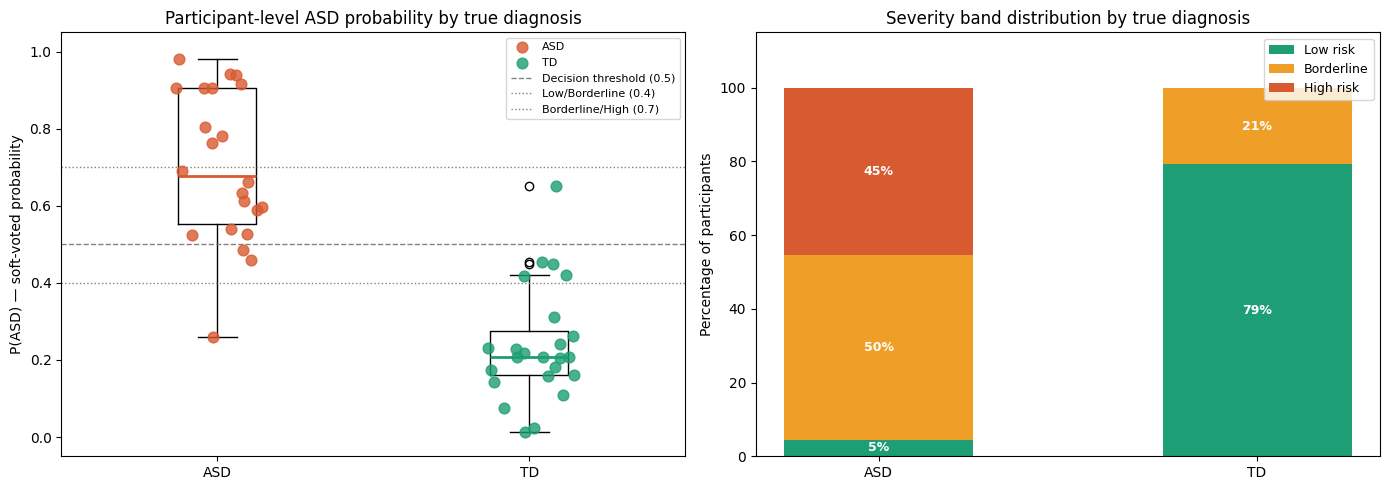

✅ Severity plot saved


In [16]:
print('─'*65)
print('  Severity Score Distribution')
print('─'*65)
print(f'  Bands: Low risk <{SEV_LOW} | Borderline {SEV_LOW}–{SEV_HIGH} | High risk ≥{SEV_HIGH}')
print()

for grp, label in [(1,'ASD'), (0,'TD')]:
    sub = part_tab[part_tab['y_true'] == grp]
    counts = sub['severity_band'].value_counts()
    print(f'  {label} participants (n={len(sub)}):')
    for band in ['Low risk','Borderline','High risk']:
        n_b = counts.get(band, 0)
        pct = 100*n_b/len(sub) if len(sub)>0 else 0
        print(f'    {band:<12}: {n_b:>2}  ({pct:>5.1f}%)')
    print(f'    Mean P(ASD)  : {sub["y_prob_mean"].mean():.3f}  ±{sub["y_prob_mean"].std():.3f}')
    print()

# ── Severity plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strip plot: P(ASD) by true group
ax = axes[0]
colors = {'ASD':'#D85A30','TD':'#1D9E75'}
for grp in ['ASD','TD']:
    sub = part_tab[part_tab['y_true'].map({1:'ASD',0:'TD'}) == grp]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(sub))
    x_pos  = (0 if grp=='ASD' else 1)
    ax.scatter(x_pos + jitter, sub['y_prob_mean'],
               color=colors[grp], alpha=0.8, s=60, zorder=3, label=grp)
    ax.boxplot(sub['y_prob_mean'].values, positions=[x_pos],
               widths=0.25, patch_artist=False,
               medianprops={'color':colors[grp],'linewidth':2})
for thresh, style, lbl in [(0.5,'--','Decision threshold (0.5)'),
                            (SEV_LOW,':',f'Low/Borderline ({SEV_LOW})'),
                            (SEV_HIGH,':',f'Borderline/High ({SEV_HIGH})')]:
    ax.axhline(thresh, color='gray', linestyle=style, linewidth=1, label=lbl)
ax.set_xticks([0,1]); ax.set_xticklabels(['ASD','TD'])
ax.set_ylabel('P(ASD) — soft-voted probability')
ax.set_title('Participant-level ASD probability by true diagnosis')
ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.05)

# Severity band stacked bar
ax = axes[1]
bands = ['Low risk','Borderline','High risk']
band_colors = ['#1D9E75','#EF9F27','#D85A30']
asd_sub = part_tab[part_tab['y_true']==1]
td_sub  = part_tab[part_tab['y_true']==0]
x = np.array([0,1])
bottoms = np.zeros(2)
for band, bc in zip(bands, band_colors):
    vals = [
        100*(asd_sub['severity_band']==band).sum()/max(len(asd_sub),1),
        100*(td_sub['severity_band']==band).sum()/max(len(td_sub),1),
    ]
    ax.bar(x, vals, bottom=bottoms, color=bc, label=band, width=0.5)
    for xi, vi, bo in zip(x, vals, bottoms):
        if vi > 3:
            ax.text(xi, bo+vi/2, f'{vi:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
ax.set_xticks([0,1]); ax.set_xticklabels(['ASD','TD'])
ax.set_ylabel('Percentage of participants')
ax.set_title('Severity band distribution by true diagnosis')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0,115)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'severity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Severity plot saved')


### Step 4 — Global Feature Importance
**TabICLv2:** Permutation importance on final model trained on all training participants.  
**XGBoost:** SHAP values (exact Shapley decomposition via `shap` library).  
Both use the globally FDR-selected features and are applied to training data — no holdout data touched.


Training final models on full training set for global importance...
   TabICLv2 final model trained
   XGBoost final model trained

Computing TabICLv2 permutation importance...


  Permutation:   0%|          | 0/12 [00:00<?, ?it/s]

Computing XGBoost SHAP values...


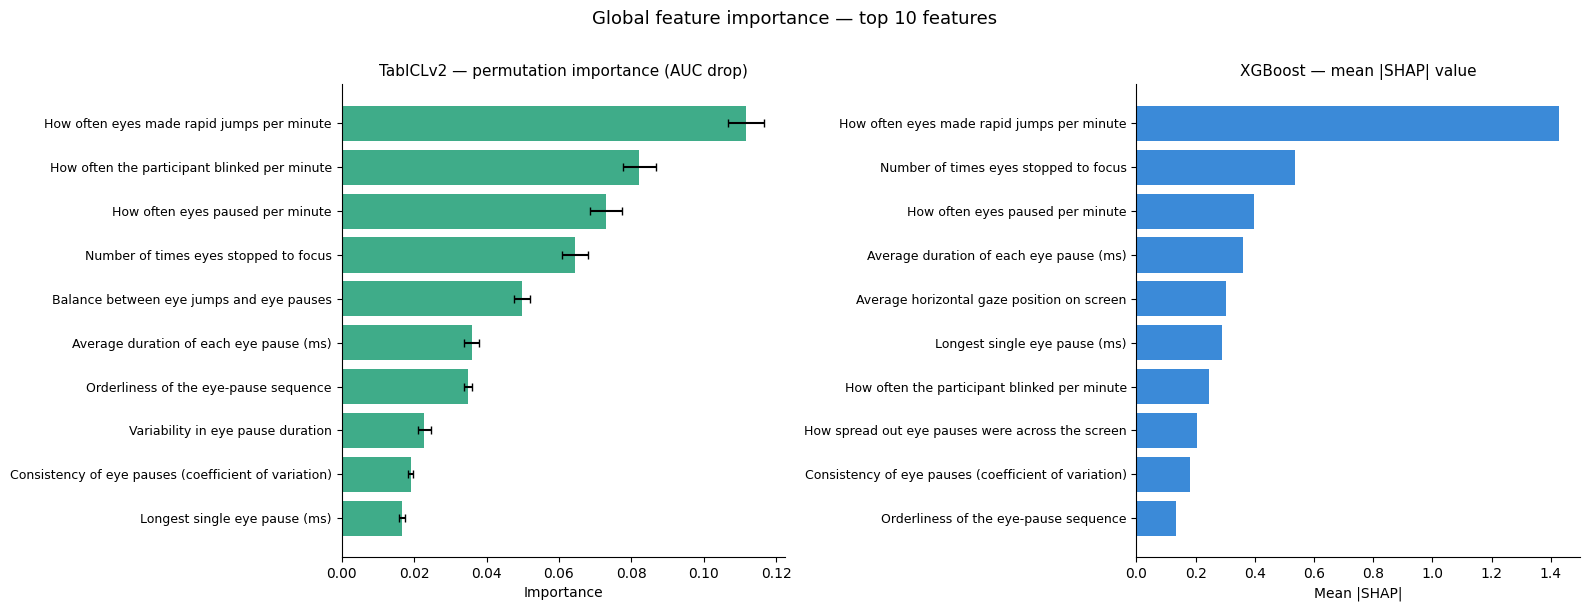

✅ Global importance plots saved


In [17]:
print('Training final models on full training set for global importance...')

# FDR on full training set (for final model features)
pm_final = df_train.groupby('participant_id')[feat_cols].mean()
pl_final = df_train.groupby('participant_id')['label'].first()
sig_final = fdr_select(pm_final, pl_final.loc[pm_final.index].values)

X_final_df = df_train[sig_final].copy()
y_final    = df_train['label'].values.astype(int)
X_final_np = X_final_df.values.astype(float)

# Train final models
final_tab = make_tabicl_finetuned(seed=RANDOM_STATE)
final_tab.fit(X_final_df, y_final)
print('   TabICLv2 final model trained')

final_xgb = make_xgb(seed=RANDOM_STATE)
final_xgb.fit(X_final_np, y_final)
print('   XGBoost final model trained')

# ── TabICLv2 permutation importance ──────────────────────────────────────────
print('\nComputing TabICLv2 permutation importance...')
baseline_tab = roc_auc_score(y_final, final_tab.predict_proba(X_final_df)[:, 1])
N_REP = 5
tab_imp_mean = np.zeros(len(sig_final))
tab_imp_std  = np.zeros(len(sig_final))
for fi, feat in enumerate(tqdm(sig_final, desc='  Permutation', leave=False)):
    scores = []
    for rep in range(N_REP):
        rng_i  = np.random.default_rng(RANDOM_STATE + fi*100 + rep)
        X_perm = X_final_df.copy()
        X_perm[feat] = rng_i.permutation(X_final_df[feat].values)
        scores.append(baseline_tab - roc_auc_score(y_final,
                          final_tab.predict_proba(X_perm)[:, 1]))
    tab_imp_mean[fi] = np.mean(scores)
    tab_imp_std[fi]  = np.std(scores)

tab_imp_df = (pd.DataFrame({
    'feature':       sig_final,
    'plain_label':   [plain(f) for f in sig_final],
    'importance':    tab_imp_mean.round(4),
    'std':           tab_imp_std.round(4),
}).sort_values('importance', ascending=False))

# ── XGBoost SHAP values ───────────────────────────────────────────────────────
print('Computing XGBoost SHAP values...')
explainer  = shap.TreeExplainer(final_xgb)
shap_vals  = explainer.shap_values(X_final_np)
# For binary classification shap may return list [class0, class1]
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
shap_mean  = np.abs(shap_vals).mean(axis=0)

xgb_imp_df = (pd.DataFrame({
    'feature':     sig_final,
    'plain_label': [plain(f) for f in sig_final],
    'shap_mean':   shap_mean.round(4),
}).sort_values('shap_mean', ascending=False))

# ── Save ──────────────────────────────────────────────────────────────────────
tab_imp_df.to_csv(os.path.join(OUTPUT_DIR,'importance_tabicl.csv'), index=False)
xgb_imp_df.to_csv(os.path.join(OUTPUT_DIR,'importance_xgb_shap.csv'), index=False)

# ── Plot side-by-side ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_imp, val_col, err_col, title, color in [
    (axes[0], tab_imp_df, 'importance', 'std',
     'TabICLv2 — permutation importance (AUC drop)', '#1D9E75'),
    (axes[1], xgb_imp_df, 'shap_mean',  None,
     'XGBoost — mean |SHAP| value', '#1976D2'),
]:
    top = df_imp.head(10)
    labels = [plain(f) for f in top['feature']]
    vals   = top[val_col].values
    errs   = top[err_col].values if err_col else None
    y_pos  = np.arange(len(top))
    ax.barh(y_pos, vals[::-1], xerr=errs[::-1] if errs is not None else None,
            color=color, alpha=0.85, capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels[::-1], fontsize=9)
    ax.set_xlabel('Importance' if val_col=='importance' else 'Mean |SHAP|')
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Global feature importance — top 10 features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'importance_global.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Global importance plots saved')


### Step 5 — Per-Participant Local Explanations (ASD-Classified)
For each participant predicted as ASD, we show which features drove the classification and provide plain-language interpretation.  
Uses the **fold's trained model** (same model that produced the prediction) — no holdout data involved.


In [19]:
def local_explanation_tabicl(fold_info, n_rep=3):
    """
    Permutation-based local importance for one participant.
    Swaps each feature one at a time; measures drop in P(ASD).
    Uses the fold's trained TabICLv2 model — identical to what made the prediction.
    """
    clf   = fold_info['tabicl']
    X_te  = fold_info['X_te_df']
    sig   = fold_info['sig_features']
    base  = fold_info['p_tab']

    imps = {}
    for feat in sig:
        drops = []
        for rep in range(n_rep):
            rng_i  = np.random.default_rng(RANDOM_STATE + rep)
            X_perm = X_te.copy()
            X_perm[feat] = rng_i.permutation(X_te[feat].values)
            p_perm = float(np.mean(clf.predict_proba(X_perm)[:, 1]))
            drops.append(base - p_perm)
        imps[feat] = float(np.mean(drops))
    return dict(sorted(imps.items(), key=lambda x: x[1], reverse=True))

def local_explanation_xgb(fold_info, explainer_xgb=None):
    """SHAP local explanation for XGBoost."""
    clf  = fold_info['xgb']
    X_te = fold_info['X_te_np']
    exp  = shap.TreeExplainer(clf)
    sv   = exp.shap_values(X_te)
    if isinstance(sv, list): sv = sv[1]
    mean_sv = sv.mean(axis=0)
    return dict(zip(fold_info['sig_features'], mean_sv.tolist()))

# ── Generate explanations for ALL participants ─────────────────────────────────
print('Generating per-participant local explanations...')
explanation_rows = []

for pid, fold_info in tqdm(fold_models.items(), desc='  Explanations'):
    p_tab   = fold_info['p_tab']
    p_xgb   = fold_info['p_xgb']
    true_lbl = fold_info['true_label']

    tab_imps = local_explanation_tabicl(fold_info)
    xgb_imps = local_explanation_xgb(fold_info)

    # Top 3 features by importance
    top3_tab = list(tab_imps.items())[:3]
    top3_xgb = sorted(xgb_imps.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

    explanation_rows.append({
        'participant_id':    pid,
        'true_label':        'ASD' if true_lbl==1 else 'TD',
        'pred_tabicl':       'ASD' if p_tab>=0.5 else 'TD',
        'pred_xgb':          'ASD' if p_xgb>=0.5 else 'TD',
        'p_asd_tabicl':      round(p_tab,3),
        'p_asd_xgb':         round(p_xgb,3),
        'severity_band':     severity_label(p_tab),
        'severity_score':    round(p_tab*100,1),
        'top1_feat':         top3_tab[0][0] if top3_tab else '',
        'top1_plain':        plain(top3_tab[0][0]) if top3_tab else '',
        'top1_importance':   round(top3_tab[0][1],4) if top3_tab else 0,
        'top2_feat':         top3_tab[1][0] if len(top3_tab)>1 else '',
        'top2_plain':        plain(top3_tab[1][0]) if len(top3_tab)>1 else '',
        'top2_importance':   round(top3_tab[1][1],4) if len(top3_tab)>1 else 0,
        'top3_feat':         top3_tab[2][0] if len(top3_tab)>2 else '',
        'top3_plain':        plain(top3_tab[2][0]) if len(top3_tab)>2 else '',
        'top3_importance':   round(top3_tab[2][1],4) if len(top3_tab)>2 else 0,
        'xgb_top1_feat':     top3_xgb[0][0] if top3_xgb else '',
        'xgb_top1_plain':    plain(top3_xgb[0][0]) if top3_xgb else '',
        'xgb_top1_shap':     round(top3_xgb[0][1],4) if top3_xgb else 0,
    })

exp_df = pd.DataFrame(explanation_rows)
exp_df.to_csv(os.path.join(OUTPUT_DIR,'participant_explanations.csv'), index=False)

# ── Print ASD-classified participants ─────────────────────────────────────────
print('\n' + '─'*75)
print('  Per-participant explanation — predicted ASD (TabICLv2)')
print('─'*75)
asd_pred = exp_df[exp_df['pred_tabicl']=='ASD'].sort_values('p_asd_tabicl', ascending=False)
for _, row in asd_pred.iterrows():
    correct = '✅' if row['true_label']==row['pred_tabicl'] else '❌'
    print(f"\n  Participant {row['participant_id']} {correct}  "          f"[true={row['true_label']}]  P(ASD)={row['p_asd_tabicl']:.3f}  "          f"Severity: {row['severity_band']} ({row['severity_score']})")
    print(f"    Why classified as ASD (TabICLv2):")
    for rank, feat_key, plain_key, imp_key in [
        ('1st', 'top1_feat','top1_plain','top1_importance'),
        ('2nd', 'top2_feat','top2_plain','top2_importance'),
        ('3rd', 'top3_feat','top3_plain','top3_importance'),
    ]:
        if row[feat_key]:
            direction = '↑ higher than TD' if row[imp_key] > 0 else '↓ lower than TD'
            print(f"      {rank}: {row[plain_key]}  [{row[feat_key]}]  "                  f"(impact={row[imp_key]:+.4f}, {direction})")

print(f'\n✅ Explanations saved → participant_explanations.csv')

Generating per-participant local explanations...


  Explanations:   0%|          | 0/46 [00:00<?, ?it/s]


───────────────────────────────────────────────────────────────────────────
  Per-participant explanation — predicted ASD (TabICLv2)
───────────────────────────────────────────────────────────────────────────

  Participant 14 ✅  [true=ASD]  P(ASD)=0.980  Severity: High risk (98.0)
    Why classified as ASD (TabICLv2):
      1st: Number of times eyes stopped to focus  [fix_count]  (impact=+0.0717, ↑ higher than TD)
      2nd: Orderliness of the eye-pause sequence  [fix_seq_norm]  (impact=+0.0539, ↑ higher than TD)
      3rd: Balance between eye jumps and eye pauses  [sac_fix_ratio]  (impact=+0.0509, ↑ higher than TD)

  Participant 7 ✅  [true=ASD]  P(ASD)=0.942  Severity: High risk (94.2)
    Why classified as ASD (TabICLv2):
      1st: Variability in eye pause duration  [fix_dur_std_ms]  (impact=+0.0136, ↑ higher than TD)
      2nd: Consistency of eye pauses (coefficient of variation)  [fix_dur_cv]  (impact=+0.0126, ↑ higher than TD)
      3rd: Longest single eye pause (ms)  [fix_dur

### Step 6 — Permutation Test (Label Shuffle)
Tests whether the observed AUC is better than chance. N_PERM=1000 for a camera-ready paper.


  Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]


  Observed AUC = 0.970  |  Null mean = 0.513  |  p = 0.0050
  ✅ Significant at α=0.05


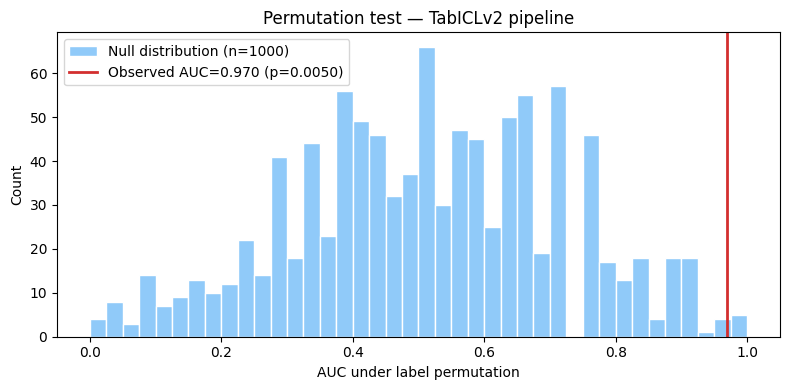

✅ Permutation test saved


In [20]:
observed_auc = ci_tab['auc'][0]

if N_PERM == 0:
    print('⏭  Permutation test skipped (N_PERM=0)')
    null_aucs, emp_p = np.array([]), float('nan')
else:
    rng      = np.random.default_rng(RANDOM_STATE)
    parts    = df_train['participant_id'].unique().tolist()
    y_arr    = df_train.groupby('participant_id')['label'].first().loc[parts].values.astype(int)
    null_aucs = []

    for i in tqdm(range(N_PERM), desc='  Permutations'):
        y_shuf = rng.permutation(y_arr)
        n      = len(parts)
        tr_idx = rng.choice(n, int(n*0.8), replace=False)
        te_idx = np.setdiff1d(np.arange(n), tr_idx)
        if len(np.unique(y_shuf[te_idx])) < 2: continue
        tr_pids = [parts[j] for j in tr_idx]
        te_pids = [parts[j] for j in te_idx]
        df_tr_p = df_train[df_train['participant_id'].isin(tr_pids)].copy()
        df_te_p = df_train[df_train['participant_id'].isin(te_pids)].copy()
        # Shuffle labels at participant level
        lmap = dict(zip(parts, y_shuf))
        df_tr_p['label'] = df_tr_p['participant_id'].map(lmap)
        pm_p = df_tr_p.groupby('participant_id')[feat_cols].mean()
        pl_p = df_tr_p.groupby('participant_id')['label'].first()
        sig_p = fdr_select(pm_p, pl_p.loc[pm_p.index].values)
        clf_p = make_tabicl(seed=RANDOM_STATE + i)
        clf_p.fit(df_tr_p[sig_p].copy(), df_tr_p['label'].values.astype(int))
        probs_p = clf_p.predict_proba(df_te_p[sig_p].copy())[:, 1]
        pdf = (pd.DataFrame({'pid': df_te_p['participant_id'].values,
                              'p': probs_p,
                              'yt': df_te_p['participant_id'].map(lmap).values})
                 .groupby('pid').agg(p=('p','mean'), yt=('yt','first')))
        if len(np.unique(pdf['yt'])) < 2: continue
        null_aucs.append(roc_auc_score(pdf['yt'], pdf['p']))

    null_aucs = np.array(null_aucs)
    emp_p     = float((null_aucs >= observed_auc).sum() / len(null_aucs))
    print(f'\n  Observed AUC = {observed_auc:.3f}  |  Null mean = {null_aucs.mean():.3f}  |  p = {emp_p:.4f}')
    print(f'  {"✅ Significant" if emp_p < ALPHA else "❌ NOT significant"} at α={ALPHA}')

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(null_aucs, bins=40, color='#90CAF9', edgecolor='white',
            label=f'Null distribution (n={len(null_aucs)})')
    ax.axvline(observed_auc, color='#D32F2F', lw=2,
               label=f'Observed AUC={observed_auc:.3f} (p={emp_p:.4f})')
    ax.set_xlabel('AUC under label permutation'); ax.set_ylabel('Count')
    ax.set_title('Permutation test — TabICLv2 pipeline'); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'permutation_test.png'), dpi=300, bbox_inches='tight')
    plt.show()
    pd.DataFrame({'observed_auc':[observed_auc], 'n_perms':[len(null_aucs)],
                  'null_mean':[round(null_aucs.mean(),4)],
                  'null_std':[round(null_aucs.std(),4)],
                  'empirical_p':[round(emp_p,4)]}).to_csv(
        os.path.join(OUTPUT_DIR,'permutation_test.csv'), index=False)
    print('✅ Permutation test saved')


### Step 7 — ROC Curves & Calibration


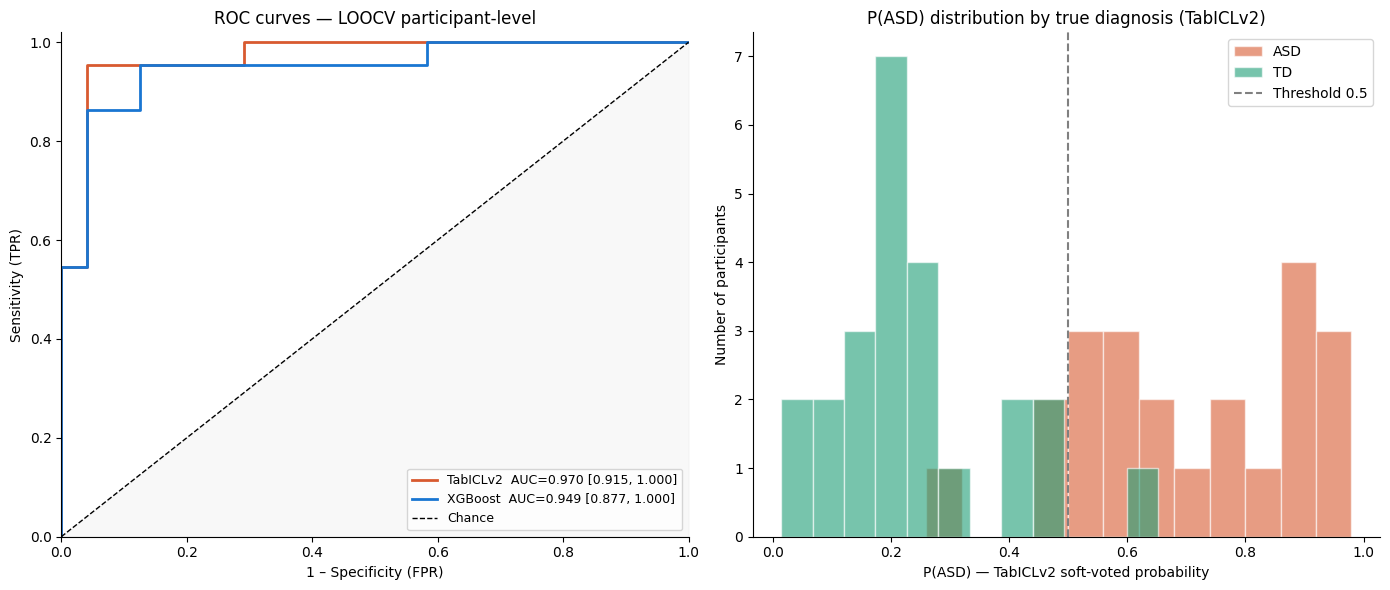

✅ ROC and distribution plots saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC curves ───────────────────────────────────────────────────────────────
ax = axes[0]
for probs, label, color, ci in [
    (part_tab['y_prob_mean'], 'TabICLv2', '#D85A30', ci_tab),
    (part_xgb['y_prob_mean'], 'XGBoost',  '#1976D2', ci_xgb),
]:
    fpr, tpr, _ = roc_curve(part_tab['y_true'], probs)
    auc_pt, auc_lo, auc_hi = ci['auc']
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{label}  AUC={auc_pt:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]')
ax.plot([0,1],[0,1],'k--',lw=1,label='Chance')
ax.fill_between([0,1],[0,1],alpha=0.05,color='gray')
ax.set_xlabel('1 – Specificity (FPR)'); ax.set_ylabel('Sensitivity (TPR)')
ax.set_title('ROC curves — LOOCV participant-level')
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Probability distributions ─────────────────────────────────────────────────
ax = axes[1]
for grp, grp_label, color in [(1,'ASD','#D85A30'), (0,'TD','#1D9E75')]:
    vals = part_tab[part_tab['y_true']==grp]['y_prob_mean'].values
    ax.hist(vals, bins=12, alpha=0.6, color=color, label=grp_label, edgecolor='white')
ax.axvline(0.5, color='gray', lw=1.5, linestyle='--', label='Threshold 0.5')
ax.set_xlabel('P(ASD) — TabICLv2 soft-voted probability')
ax.set_ylabel('Number of participants')
ax.set_title('P(ASD) distribution by true diagnosis (TabICLv2)')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'roc_and_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ ROC and distribution plots saved')


### Step 8 — Holdout Evaluation (ONE-TIME, gated)
> This cell runs **once only**. A flag file prevents repeated evaluation to eliminate p-hacking. Do not delete the flag file unless you have a genuinely new train/test split.


In [22]:
if os.path.exists(HOLDOUT_FLAG):
    print('*** HOLDOUT ALREADY EVALUATED — skipping to prevent p-hacking ***')
    print(f'    Flag: {HOLDOUT_FLAG}')
else:
    X_hold_df = df_holdout[sig_final].copy()
    X_hold_np = X_hold_df.values.astype(float)
    y_hold    = df_holdout['label'].values.astype(int)

    probs_hold_tab = final_tab.predict_proba(X_hold_df)[:, 1]
    probs_hold_xgb = final_xgb.predict_proba(X_hold_np)[:, 1]

    part_hold_tab = aggregate_to_participant(
        df_holdout['participant_id'].values, y_hold, probs_hold_tab, threshold=0.5)
    part_hold_xgb = aggregate_to_participant(
        df_holdout['participant_id'].values, y_hold, probs_hold_xgb, threshold=0.5)
    part_hold_tab = add_severity(part_hold_tab)

    hold_ci_tab = bootstrap_metrics(part_hold_tab['y_true'], part_hold_tab['y_prob_mean'],
                                    threshold=0.5, n_boot=N_BOOT)
    hold_ci_xgb = bootstrap_metrics(part_hold_xgb['y_true'], part_hold_xgb['y_prob_mean'],
                                    threshold=0.5, n_boot=N_BOOT)

    print_metrics(hold_ci_tab, f'TabICLv2 HOLDOUT (n={len(part_hold_tab)}, threshold=0.500)',
                  len(part_hold_tab), 0.5)
    print_metrics(hold_ci_xgb, f'XGBoost HOLDOUT (n={len(part_hold_xgb)}, threshold=0.500)',
                  len(part_hold_xgb), 0.5)

    with open(HOLDOUT_FLAG, 'w') as f: f.write(datetime.datetime.now().isoformat())
    part_hold_tab.to_csv(os.path.join(OUTPUT_DIR,'holdout_tabicl.csv'), index=False)
    part_hold_xgb.to_csv(os.path.join(OUTPUT_DIR,'holdout_xgb.csv'), index=False)
    print('\n✅ Holdout results saved (flag written — will not re-run)')



─────────────────────────────────────────────────────────────────
  TabICLv2 HOLDOUT (n=11, threshold=0.500)
  n=11 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 1.000  [1.000, 1.000]
  Sensitivity         1.000  [1.000, 1.000]
  Specificity         0.667  [0.250, 1.000]
  F1                  0.833  [0.500, 1.000]
  Accuracy            0.818  [0.545, 1.000]
  Brier score         0.103  [0.044, 0.181]
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
  XGBoost HOLDOUT (n=11, threshold=0.500)
  n=11 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 1.000  [1.000, 1.000]
  Sensitivity         1.000  [1.000, 1.000]
  Specificity         0.833  [0.500, 1.000]
  F1                  0.909  [0.667, 1.000]
  Accuracy            0.909  [0.727, 1.000]
  Brier score      

In [23]:
print('\n' + '='*70)
print('  FINAL SUMMARY')
print('='*70)
print(f'\n  Dataset      : {n_all} participants  (ASD={asd_n}, TD={td_n})')
print(f'  Train        : {len(train_ids)} participants  |  Holdout: {len(holdout_ids)}')
print(f'  Features     : {len(sig_final)} survived FDR (from {len(feat_cols)})')
print(f'  LOOCV folds  : {df_train["participant_id"].nunique()}  (one per participant)')
print(f'  Threshold    : 0.500 (primary)  |  Youden-J {best_thresh_tab:.3f} (secondary)')

print(f'\n  ── TabICLv2 LOOCV ──')
for k,(pt,lo,hi) in ci_tab.items():
    n = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
         'f1':'F1','acc':'Accuracy','brier':'Brier'}.get(k,k)
    print(f'    {n:<14} {pt:.3f}  [{lo:.3f}, {hi:.3f}]')
print(f"    Cohen's d    {d_tab:.3f}")

print(f'\n  ── XGBoost LOOCV ──')
for k,(pt,lo,hi) in ci_xgb.items():
    n = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
         'f1':'F1','acc':'Accuracy','brier':'Brier'}.get(k,k)
    print(f'    {n:<14} {pt:.3f}  [{lo:.3f}, {hi:.3f}]')
print(f"    Cohen's d    {d_xgb:.3f}")

print(f'\n  ── Statistical tests ──')
print(f'    McNemar p            : {mc.pvalue:.4f}')
print(f'    Permutation p        : {emp_p:.4f}  (N={len(null_aucs)})')

print(f'\n  ── Severity (TabICLv2, training set) ──')
for band in ['Low risk','Borderline','High risk']:
    n_b = (part_tab['severity_band']==band).sum()
    print(f'    {band:<12}: {n_b} participants')

print(f'\n  ── Outputs in {OUTPUT_DIR}/ ──')
outputs = [
    'split_indices.json', 'feature_statistics.csv',
    'loocv_fold_results.csv', 'loocv_tabicl_participants.csv', 'loocv_xgb_participants.csv',
    'metrics_tabicl.csv', 'metrics_xgb.csv',
    'mcnemar_test.csv', 'permutation_test.csv', 'permutation_test.png',
    'importance_tabicl.csv', 'importance_xgb_shap.csv', 'importance_global.png',
    'participant_explanations.csv', 'severity_distribution.png',
    'roc_and_distributions.png',
    'holdout_tabicl.csv', 'holdout_xgb.csv',
]
for fname in outputs:
    p = os.path.join(OUTPUT_DIR, fname)
    tag = '✅' if os.path.exists(p) else '  (pending)'
    print(f'  {tag}  {fname}')
print('='*70)



  FINAL SUMMARY

  Dataset      : 57 participants  (ASD=27, TD=30)
  Train        : 46 participants  |  Holdout: 11
  Features     : 12 survived FDR (from 28)
  LOOCV folds  : 46  (one per participant)
  Threshold    : 0.500 (primary)  |  Youden-J 0.459 (secondary)

  ── TabICLv2 LOOCV ──
    AUC            0.970  [0.915, 1.000]
    Sensitivity    0.864  [0.704, 1.000]
    Specificity    0.958  [0.862, 1.000]
    F1             0.905  [0.800, 0.980]
    Accuracy       0.913  [0.826, 0.978]
    Brier          0.101  [0.070, 0.137]
    Cohen's d    2.725

  ── XGBoost LOOCV ──
    AUC            0.949  [0.877, 1.000]
    Sensitivity    0.864  [0.704, 1.000]
    Specificity    0.958  [0.862, 1.000]
    F1             0.905  [0.800, 0.980]
    Accuracy       0.913  [0.826, 0.978]
    Brier          0.111  [0.078, 0.148]
    Cohen's d    2.508

  ── Statistical tests ──
    McNemar p            : 1.0000
    Permutation p        : 0.0050  (N=1000)

  ── Severity (TabICLv2, training set) ──
